<a href="https://colab.research.google.com/github/Motilipz/Drugs-side-Effects-Analysis/blob/main/SVM%20%26%20Naive%20bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pratical Questions

Q21. Write a Python program to train an SVM Classifier on the Iris dataset and evaluate accuracy:

In [57]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create an SVM Classifier
# Using a linear kernel for simplicity, but 'rbf' (default) is also common
svm_classifier = svm.SVC(kernel='linear', random_state=42)

# Train the classifier on the training data
svm_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred = svm_classifier.predict(X_test)

# Evaluate the accuracy of the classifier
accuracy = accuracy_score(y_test, y_pred)
print(f"SVM Classifier Accuracy on Iris dataset: {accuracy:.4f}")

SVM Classifier Accuracy on Iris dataset: 1.0000


Q22. Write a Python program to train two SVM classifiers with Linear and RBF kernels on the Wine dataset, then
compare their accuracies:

In [58]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

# Load the Wine dataset
wine = datasets.load_wine()
X = wine.data
y = wine.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create an SVM Classifier with Linear Kernel
svm_linear = svm.SVC(kernel='linear', random_state=42)

# Train the Linear SVM classifier
svm_linear.fit(X_train, y_train)

# Make predictions with the Linear SVM
y_pred_linear = svm_linear.predict(X_test)

# Evaluate the accuracy of the Linear SVM classifier
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f"SVM Classifier Accuracy (Linear Kernel) on Wine dataset: {accuracy_linear:.4f}")

# Create an SVM Classifier with RBF Kernel (default kernel)
svm_rbf = svm.SVC(kernel='rbf', random_state=42)

# Train the RBF SVM classifier
svm_rbf.fit(X_train, y_train)

# Make predictions with the RBF SVM
y_pred_rbf = svm_rbf.predict(X_test)

# Evaluate the accuracy of the RBF SVM classifier
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"SVM Classifier Accuracy (RBF Kernel) on Wine dataset: {accuracy_rbf:.4f}")

# Compare accuracies
if accuracy_linear > accuracy_rbf:
    print("\nLinear Kernel performed better.")
elif accuracy_rbf > accuracy_linear:
    print("\nRBF Kernel performed better.")
else:
    print("\nBoth Linear and RBF Kernels performed equally well.")

SVM Classifier Accuracy (Linear Kernel) on Wine dataset: 0.9815
SVM Classifier Accuracy (RBF Kernel) on Wine dataset: 0.7593

Linear Kernel performed better.


Q23. Write a Python program to train an SVM Regressor (SVR) on a housing dataset and evaluate it using Mean
Squared Error (MSE)/

In [63]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import mean_squared_error
import numpy as np

# Load a housing dataset (e.g., Boston House Prices dataset)
# Note: Boston dataset is deprecated in scikit-learn 1.2 and removed in 1.4
# For newer versions, consider using fetch_california_housing or creating a synthetic dataset.
try:
    boston = datasets.load_boston()
    X = boston.data
    y = boston.target
    dataset_name = "Boston House Prices"
except ImportError: # Changed from AttributeError to ImportError
    # Fallback to California Housing if load_boston is not available
    print("Boston dataset deprecated or not found. Using California Housing dataset instead.")
    california = datasets.fetch_california_housing()
    X = california.data
    y = california.target
    dataset_name = "California Housing"

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create an SVR model
# Using a radial basis function (RBF) kernel, which is common for SVR
# C and gamma are hyperparameters that often need tuning
svr_model = svm.SVR(kernel='rbf', C=100, gamma=0.1)

# Train the SVR model
svr_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_svr = svr_model.predict(X_test)

# Evaluate the model using Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred_svr)
rmse = np.sqrt(mse)

print(f"SVR Model trained on {dataset_name} dataset:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Boston dataset deprecated or not found. Using California Housing dataset instead.
SVR Model trained on California Housing dataset:
Mean Squared Error (MSE): 1.1301
Root Mean Squared Error (RMSE): 1.0630


Q24. Write a Python program to train an SVM Classifier with a Polynomial Kernel and visualize the decision boundary.

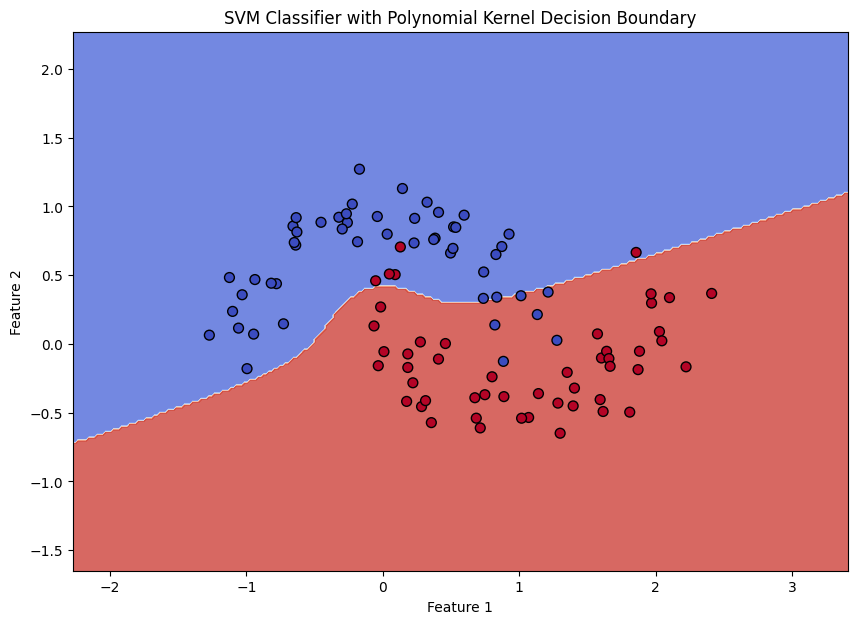

SVM Classifier Accuracy (Polynomial Kernel): 0.9333


In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# 1. Generate a synthetic dataset for visualization (2D data)
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Create an SVM Classifier with a Polynomial Kernel
# 'degree' parameter controls the polynomial degree
# 'C' and 'gamma' are hyperparameters that often need tuning
svm_poly = svm.SVC(kernel='poly', degree=3, C=1, gamma='auto', random_state=42)

# Train the classifier on the training data
svm_poly.fit(X_train, y_train)

# 3. Visualize the decision boundary
# Create a mesh to plot in
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict class for each point in the mesh
Z = svm_poly.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and the data points
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, edgecolors='k', cmap=plt.cm.coolwarm)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVM Classifier with Polynomial Kernel Decision Boundary')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.show()

# Evaluate accuracy (optional, as the focus is on visualization here)
accuracy = svm_poly.score(X_test, y_test)
print(f"SVM Classifier Accuracy (Polynomial Kernel): {accuracy:.4f}")

Q25. Write a Python program to train a Gaussian Naïve Bayes classifier on the Breast Cancer dataset and evaluate accuracy.

In [62]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Load the Breast Cancer dataset
breast_cancer = datasets.load_breast_cancer()
X = breast_cancer.data
y = breast_cancer.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a Gaussian Naïve Bayes classifier
gnb = GaussianNB()

# Train the classifier on the training data
gnb.fit(X_train, y_train)

# Make predictions on the test data
y_pred = gnb.predict(X_test)

# Evaluate the accuracy of the classifier
accuracy = accuracy_score(y_test, y_pred)
print(f"Gaussian Naïve Bayes Classifier Accuracy on Breast Cancer dataset: {accuracy:.4f}")

Gaussian Naïve Bayes Classifier Accuracy on Breast Cancer dataset: 0.9415


Q26. Write a Python program to train a Multinomial Naive Bayes classifier for text classification using the 20 Newsgroups dataset.

In [86]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the 20 Newsgroups dataset
# We'll load a subset of categories for quicker demonstration
categories = ['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian']
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories, shuffle=True, random_state=42)

X_train = newsgroups_train.data
y_train = newsgroups_train.target
X_test = newsgroups_test.data
y_test = newsgroups_test.target

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Categories: {newsgroups_train.target_names}")

# 2. Convert text data into numerical feature vectors using CountVectorizer
# CountVectorizer converts a collection of text documents to a matrix of token counts
vectorizer = CountVectorizer()
X_train_vectors = vectorizer.fit_transform(X_train)
X_test_vectors = vectorizer.transform(X_test)

print(f"Number of features (vocabulary size): {len(vectorizer.vocabulary_)}")

# 3. Create a Multinomial Naïve Bayes classifier
# MultinomialNB is well-suited for classification with discrete features (like word counts)
mnb_classifier = MultinomialNB()

# 4. Train the classifier on the training data
mnb_classifier.fit(X_train_vectors, y_train)

# 5. Make predictions on the test data
y_pred = mnb_classifier.predict(X_test_vectors)

# 6. Evaluate the accuracy of the classifier
accuracy = accuracy_score(y_test, y_pred)
print(f"\nMultinomial Naive Bayes Classifier Accuracy: {accuracy:.4f}")

# Print a detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=newsgroups_test.target_names))

Training samples: 2257
Testing samples: 1502
Categories: ['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian']
Number of features (vocabulary size): 35788

Multinomial Naive Bayes Classifier Accuracy: 0.9341

Classification Report:
                         precision    recall  f1-score   support

           alt.atheism       0.92      0.90      0.91       319
         comp.graphics       0.95      0.95      0.95       389
               sci.med       0.96      0.91      0.93       396
soc.religion.christian       0.91      0.97      0.94       398

              accuracy                           0.93      1502
             macro avg       0.93      0.93      0.93      1502
          weighted avg       0.93      0.93      0.93      1502



Q27. Write a Python program to train an SVM Classifier with different C values and compare the decision boundaries visually.

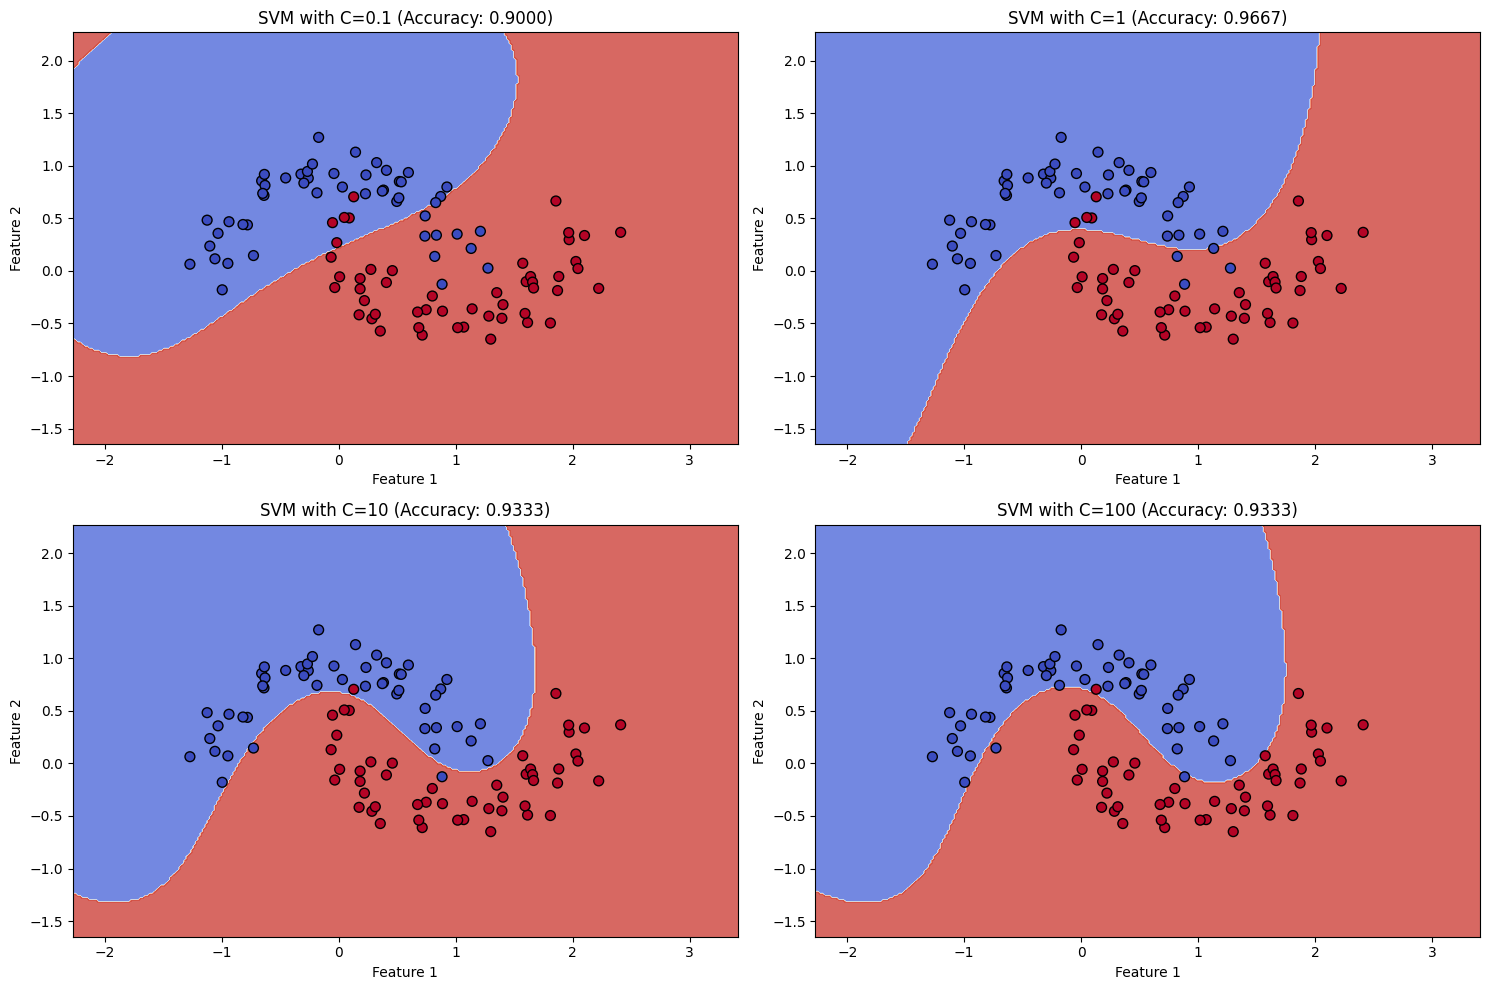

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# 1. Generate a synthetic dataset for visualization (2D data)
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define different C values to compare
C_values = [0.1, 1, 10, 100]

# Create a mesh to plot in
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

plt.figure(figsize=(15, 10))

# Iterate over different C values
for i, C in enumerate(C_values):
    # Create an SVM Classifier with an RBF kernel and current C value
    # RBF kernel is generally good for non-linear boundaries
    svm_classifier = svm.SVC(kernel='rbf', C=C, gamma='auto', random_state=42)

    # Train the classifier on the training data
    svm_classifier.fit(X_train, y_train)

    # Predict class for each point in the mesh
    Z = svm_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary and the data points
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=50, edgecolors='k', cmap=plt.cm.coolwarm)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(f'SVM with C={C} (Accuracy: {svm_classifier.score(X_test, y_test):.4f})')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

plt.tight_layout()
plt.show()

Q28. Write a Python program to train a Bernoulli Naïve Bayes classifier for binary classification on a dataset with binary features.

In [66]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Generate a synthetic dataset with binary features
# Let's create a dataset where features are binary (0 or 1)
# and there's a clear separation between two classes.
np.random.seed(42)
X_binary = np.random.randint(0, 2, size=(200, 10)) # 200 samples, 10 binary features

# Create a target variable (binary classification)
# For simplicity, let's say class 0 is when the sum of first 5 features is <= 2
# and class 1 when sum of first 5 features is > 2
y_binary = (np.sum(X_binary[:, :5], axis=1) > 2).astype(int)

print(f"Shape of X_binary: {X_binary.shape}")
print(f"Shape of y_binary: {y_binary.shape}")
print(f"First 5 samples of X_binary:\n{X_binary[:5]}")
print(f"First 5 samples of y_binary: {y_binary[:5]}\n")

# 2. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_binary, y_binary, test_size=0.3, random_state=42)

# 3. Create a Bernoulli Naïve Bayes classifier
bnb_classifier = BernoulliNB()

# 4. Train the classifier on the training data
bnb_classifier.fit(X_train, y_train)

# 5. Make predictions on the test data
y_pred_bnb = bnb_classifier.predict(X_test)

# 6. Evaluate the accuracy of the classifier
accuracy_bnb = accuracy_score(y_test, y_pred_bnb)
print(f"Bernoulli Naïve Bayes Classifier Accuracy: {accuracy_bnb:.4f}")

Shape of X_binary: (200, 10)
Shape of y_binary: (200,)
First 5 samples of X_binary:
[[0 1 0 0 0 1 0 0 0 1]
 [0 0 0 0 1 0 1 1 1 0]
 [1 0 1 1 1 1 1 1 1 1]
 [0 0 1 1 1 0 1 0 0 0]
 [0 0 1 1 1 1 1 0 1 1]]
First 5 samples of y_binary: [0 0 1 1 1]

Bernoulli Naïve Bayes Classifier Accuracy: 0.9333


Q29. Write a Python program to apply feature scaling before training an SVM model and compare results with unscaled data.

In [67]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Load the Breast Cancer dataset
breast_cancer = datasets.load_breast_cancer()
X = breast_cancer.data
y = breast_cancer.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("--- SVM without Feature Scaling ---")
# Create an SVM Classifier without scaling
svm_unscaled = svm.SVC(kernel='rbf', random_state=42)

# Train the classifier on the original (unscaled) training data
svm_unscaled.fit(X_train, y_train)

# Make predictions on the original (unscaled) test data
y_pred_unscaled = svm_unscaled.predict(X_test)

# Evaluate accuracy for the unscaled model
accuracy_unscaled = accuracy_score(y_test, y_pred_unscaled)
print(f"Accuracy with unscaled data: {accuracy_unscaled:.4f}")

print("\n--- SVM with Feature Scaling ---")
# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create an SVM Classifier with scaling
# It's important to re-initialize the SVM or at least fit on scaled data
svm_scaled = svm.SVC(kernel='rbf', random_state=42)

# Train the classifier on the scaled training data
svm_scaled.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_scaled = svm_scaled.predict(X_test_scaled)

# Evaluate accuracy for the scaled model
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)
print(f"Accuracy with scaled data: {accuracy_scaled:.4f}")

print("\n--- Comparison ---")
if accuracy_scaled > accuracy_unscaled:
    print("Feature scaling improved the model's accuracy.")
elif accuracy_unscaled > accuracy_scaled:
    print("Model performed better without feature scaling (uncommon for SVMs). No significant impact or slightly worse.")
else:
    print("Feature scaling had no significant impact on the model's accuracy.")

--- SVM without Feature Scaling ---
Accuracy with unscaled data: 0.9357

--- SVM with Feature Scaling ---
Accuracy with scaled data: 0.9766

--- Comparison ---
Feature scaling improved the model's accuracy.


Q30. Write a Python program to train a Gaussian Naïve Bayes model and compare the predictions before and after Laplace Smoothing.

In [68]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import numpy as np

# Load a dataset (e.g., Iris dataset)
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("--- Gaussian Naïve Bayes with default var_smoothing ---")
# Create a Gaussian Naïve Bayes classifier with default var_smoothing
# Default var_smoothing is 1e-9
gnb_default = GaussianNB()

# Train the classifier
gnb_default.fit(X_train, y_train)

# Make predictions
y_pred_default = gnb_default.predict(X_test)

# Evaluate accuracy
accuracy_default = accuracy_score(y_test, y_pred_default)
print(f"Accuracy (default var_smoothing): {accuracy_default:.4f}")

print("\n--- Gaussian Naïve Bayes with increased var_smoothing ---")
# Create a Gaussian Naïve Bayes classifier with increased var_smoothing
# A larger var_smoothing value means more smoothing (less sensitive to individual feature variances)
gnb_smoothed = GaussianNB(var_smoothing=1e-5) # Increased smoothing

# Train the classifier
gnb_smoothed.fit(X_train, y_train)

# Make predictions
y_pred_smoothed = gnb_smoothed.predict(X_test)

# Evaluate accuracy
accuracy_smoothed = accuracy_score(y_test, y_pred_smoothed)
print(f"Accuracy (increased var_smoothing): {accuracy_smoothed:.4f}")

print("\n--- Comparison ---")
print(f"Predictions with default var_smoothing: {y_pred_default}")
print(f"Predictions with increased var_smoothing: {y_pred_smoothed}")

# Compare if predictions are different
if not np.array_equal(y_pred_default, y_pred_smoothed):
    print("\nPredictions differ between default and increased var_smoothing.")
else:
    print("\nPredictions are identical between default and increased var_smoothing.")

# Explain the var_smoothing parameter
print("\nNote: For Gaussian Naïve Bayes, 'var_smoothing' acts as a form of smoothing. ")
print("It adds a small value to the variance of each feature to prevent issues with zero variance ")
print("and can influence the model's sensitivity to individual feature distributions.")

--- Gaussian Naïve Bayes with default var_smoothing ---
Accuracy (default var_smoothing): 0.9778

--- Gaussian Naïve Bayes with increased var_smoothing ---
Accuracy (increased var_smoothing): 0.9778

--- Comparison ---
Predictions with default var_smoothing: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 2 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]
Predictions with increased var_smoothing: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 2 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]

Predictions are identical between default and increased var_smoothing.

Note: For Gaussian Naïve Bayes, 'var_smoothing' acts as a form of smoothing. 
It adds a small value to the variance of each feature to prevent issues with zero variance 
and can influence the model's sensitivity to individual feature distributions.


Q31. Write a Python program to train an SVM Classifier and use GridSearchCV to tune the hyperparameters (C, gamma, kernel).

In [69]:
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import svm
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define the parameter grid to search
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear'] # RBF is common, linear is simple
}

# Create an SVM Classifier instance
svm_model = svm.SVC(random_state=42)

# Create GridSearchCV object
# cv=5 means 5-fold cross-validation
# verbose=1 shows progress
# n_jobs=-1 uses all available CPU cores
grid_search = GridSearchCV(svm_model, param_grid, cv=5, verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters found
print("\nBest parameters found:", grid_search.best_params_)

# Print the best cross-validation score (average accuracy across folds)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Get the best estimator (model) from GridSearchCV
best_svm_model = grid_search.best_estimator_

# Make predictions on the test data using the best model
y_pred_tuned = best_svm_model.predict(X_test)

# Evaluate the accuracy of the best model on the unseen test data
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Test set accuracy with best parameters: {accuracy_tuned:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best parameters found: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Best cross-validation accuracy: 0.9714285714285715
Test set accuracy with best parameters: 1.0000


Q32. Write a Python program to train an SVM Classifier on an imbalanced dataset and apply class weighting and check it improve accuracy.

In [70]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# 1. Generate an imbalanced dataset
# Let's create a dataset with 1000 samples, 2 features, and 2 classes.
# We'll make it imbalanced with 90% in class 0 and 10% in class 1.
X, y = make_classification(n_samples=1000,
                           n_features=2,
                           n_informative=2,
                           n_redundant=0,
                           n_repeated=0,
                           n_classes=2,
                           n_clusters_per_class=1,
                           weights=[0.90, 0.10], # 90% majority, 10% minority
                           flip_y=0,
                           random_state=42)

print(f"Original dataset shape: X={X.shape}, y={y.shape}")
print(f"Class distribution: {np.bincount(y)}\n")

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) # stratify to maintain class distribution

print(f"Training set class distribution: {np.bincount(y_train)}")
print(f"Test set class distribution: {np.bincount(y_test)}\n")

# --- 2. Train an SVM Classifier without class weighting (Baseline) ---
print("--- SVM without Class Weighting ---")
svm_unweighted = svm.SVC(kernel='linear', random_state=42)
svm_unweighted.fit(X_train, y_train)
y_pred_unweighted = svm_unweighted.predict(X_test)

accuracy_unweighted = accuracy_score(y_test, y_pred_unweighted)
print(f"Accuracy (unweighted): {accuracy_unweighted:.4f}")
print("Classification Report (unweighted):\n", classification_report(y_test, y_pred_unweighted))

# --- 3. Train an SVM Classifier with class weighting ---
print("\n--- SVM with Class Weighting ---")
# 'balanced' mode automatically adjusts weights inversely proportional to class frequencies
svm_weighted = svm.SVC(kernel='linear', class_weight='balanced', random_state=42)
svm_weighted.fit(X_train, y_train)
y_pred_weighted = svm_weighted.predict(X_test)

accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
print(f"Accuracy (weighted): {accuracy_weighted:.4f}")
print("Classification Report (weighted):\n", classification_report(y_test, y_pred_weighted))

# --- 4. Compare results ---
print("\n--- Comparison of Results ---")
print(f"Accuracy without class weighting: {accuracy_unweighted:.4f}")
print(f"Accuracy with class weighting: {accuracy_weighted:.4f}")

# Focus on the minority class (class 1 in this example)
report_unweighted = classification_report(y_test, y_pred_unweighted, output_dict=True)
report_weighted = classification_report(y_test, y_pred_weighted, output_dict=True)

f1_unweighted_minority = report_unweighted['1']['f1-score']
f1_weighted_minority = report_weighted['1']['f1-score']

print(f"F1-score for minority class (unweighted): {f1_unweighted_minority:.4f}")
print(f"F1-score for minority class (weighted): {f1_weighted_minority:.4f}")

if f1_weighted_minority > f1_unweighted_minority:
    print("\nClass weighting improved the F1-score for the minority class.")
elif f1_weighted_minority < f1_unweighted_minority:
    print("\nClass weighting slightly decreased the F1-score for the minority class (might be a trade-off with overall accuracy).")
else:
    print("\nClass weighting had no significant impact on the F1-score for the minority class.")


Original dataset shape: X=(1000, 2), y=(1000,)
Class distribution: [900 100]

Training set class distribution: [630  70]
Test set class distribution: [270  30]

--- SVM without Class Weighting ---
Accuracy (unweighted): 0.9933
Classification Report (unweighted):
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       270
           1       1.00      0.93      0.97        30

    accuracy                           0.99       300
   macro avg       1.00      0.97      0.98       300
weighted avg       0.99      0.99      0.99       300


--- SVM with Class Weighting ---
Accuracy (weighted): 0.9800
Classification Report (weighted):
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       270
           1       0.88      0.93      0.90        30

    accuracy                           0.98       300
   macro avg       0.93      0.96      0.95       300
weighted avg       0.98      0.98      0

Q33. Write a Python program to implement a Naïve Bayes classifier for spam detection using email data.

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# 1. Create a synthetic dataset of emails (spam vs. ham)
# For a real application, you would load a much larger dataset.
emails = [
    "Congratulations! You've won a free iPhone. Click here now!", # Spam
    "Hi John, let's meet tomorrow to discuss the project. Regards, Mary", # Ham
    "Urgent: Your account has been compromised. Verify your details immediately.", # Spam
    "Meeting scheduled for Friday at 10 AM. See you there.", # Ham
    "Free money! Claim your prize now. Limited time offer.", # Spam
    "Hello, please review the attached document. Thanks.", # Ham
    "Lose weight fast with our new diet pill! Order today.", # Spam
    "Regarding the Q3 report, please send your updates by EOD.", # Ham
    "$$$ Make millions from home! Click this link! $$$ ", # Spam
    "Could you please confirm your availability for next week?", # Ham
    "Exclusive offer: Get 50% off all products. Limited stock.", # Spam
    "Project update: New features have been deployed. Check it out.", # Ham
    "Warning: Your credit card payment failed. Update now to avoid suspension.", # Spam
    "Just checking in. How are things going with the task?", # Ham
    "You have been selected for a lottery prize! Reply to claim.", # Spam
    "Reminder: Team sync-up call at 2 PM. Don't be late!", # Ham
    "Unsubscribe here to stop receiving these emails.", # Spam (often found in spam to bypass filters)
    "Re: Your request - I've sent the files over.", # Ham
    "Amazing discount! Buy now and save big!", # Spam
    "Quick question about your last email.", # Ham
]

# Labels: 1 for spam, 0 for ham
labels = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

# 2. Split the data into training and testing sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(emails, labels, test_size=0.3, random_state=42)

# 3. Convert text data into numerical feature vectors using CountVectorizer
# CountVectorizer converts a collection of text documents to a matrix of token counts
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw)

# 4. Create a Multinomial Naïve Bayes classifier
# MultinomialNB is well-suited for classification with discrete features (like word counts)
mnb_spam = MultinomialNB()

# 5. Train the classifier on the training data
mnb_spam.fit(X_train, y_train)

# 6. Make predictions on the test data
y_pred_spam = mnb_spam.predict(X_test)

# 7. Evaluate the accuracy of the classifier
accuracy_spam = accuracy_score(y_test, y_pred_spam)
print(f"Naïve Bayes Spam Detector Accuracy: {accuracy_spam:.4f}")

# Print a detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_spam, target_names=['Ham', 'Spam']))

# Example: Predict on new unseen email
new_emails = [
    "Hello, your invoice is attached. Please process it.",
    "Winning lottery notification! Claim your prize now.",
    "Important security update: Your password has expired."
]
new_emails_vectorized = vectorizer.transform(new_emails)
predictions = mnb_spam.predict(new_emails_vectorized)

print("\nPredictions for new emails:")
for i, email in enumerate(new_emails):
    print(f"'{email}' -> {'Spam' if predictions[i] == 1 else 'Ham'}")

Naïve Bayes Spam Detector Accuracy: 1.0000

Classification Report:
               precision    recall  f1-score   support

         Ham       1.00      1.00      1.00         4
        Spam       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6


Predictions for new emails:
'Hello, your invoice is attached. Please process it.' -> Ham
'Winning lottery notification! Claim your prize now.' -> Spam
'Important security update: Your password has expired.' -> Spam


Q34. Write a Python program to train an SVM Classifier and a Naïve Bayes Classifier on the same dataset and compare their accuracy.

In [72]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("--- SVM Classifier ---")
# Create an SVM Classifier
svm_classifier = svm.SVC(kernel='linear', random_state=42)

# Train the SVM classifier
svm_classifier.fit(X_train, y_train)

# Make predictions with SVM
y_pred_svm = svm_classifier.predict(X_test)

# Evaluate SVM accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Classifier Accuracy: {accuracy_svm:.4f}")

print("\n--- Gaussian Naïve Bayes Classifier ---")
# Create a Gaussian Naïve Bayes classifier
gnb_classifier = GaussianNB()

# Train the Naïve Bayes classifier
gnb_classifier.fit(X_train, y_train)

# Make predictions with Naïve Bayes
y_pred_gnb = gnb_classifier.predict(X_test)

# Evaluate Naïve Bayes accuracy
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
print(f"Gaussian Naïve Bayes Classifier Accuracy: {accuracy_gnb:.4f}")

print("\n--- Comparison ---")
if accuracy_svm > accuracy_gnb:
    print(f"SVM Classifier performed better with an accuracy of {accuracy_svm:.4f}")
elif accuracy_gnb > accuracy_svm:
    print(f"Gaussian Naïve Bayes Classifier performed better with an accuracy of {accuracy_gnb:.4f}")
else:
    print(f"Both classifiers performed equally well with an accuracy of {accuracy_svm:.4f}")

--- SVM Classifier ---
SVM Classifier Accuracy: 1.0000

--- Gaussian Naïve Bayes Classifier ---
Gaussian Naïve Bayes Classifier Accuracy: 0.9778

--- Comparison ---
SVM Classifier performed better with an accuracy of 1.0000


Q35. Write a Python program to perform feature selection before training a Naïve Bayes classifier and compare results.

In [73]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import RFE
from sklearn.svm import SVC # RFE needs an estimator with 'coef_' or 'feature_importances_'

# Load the Breast Cancer dataset
breast_cancer = datasets.load_breast_cancer()
X = breast_cancer.data
y = breast_cancer.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("--- Naïve Bayes without Feature Selection ---")
# 1. Train Gaussian Naïve Bayes without feature selection (Baseline)
gnb_unfiltered = GaussianNB()
gnb_unfiltered.fit(X_train, y_train)
y_pred_unfiltered = gnb_unfiltered.predict(X_test)
accuracy_unfiltered = accuracy_score(y_test, y_pred_unfiltered)
print(f"Accuracy without feature selection: {accuracy_unfiltered:.4f}")

print("\n--- Naïve Bayes with Feature Selection (RFE) ---")
# 2. Apply Feature Selection using RFE
# RFE requires an estimator that has a 'coef_' or 'feature_importances_' attribute.
# GaussianNB does not have this, so we'll use an SVM as the estimator for RFE
# and then train GaussianNB on the selected features.
estimator_for_rfe = SVC(kernel="linear", C=1, random_state=42) # Using linear SVM for RFE
rfe_selector = RFE(estimator=estimator_for_rfe, n_features_to_select=10, step=1) # Select top 10 features

rfe_selector.fit(X_train, y_train)

X_train_selected = rfe_selector.transform(X_train)
X_test_selected = rfe_selector.transform(X_test)

print(f"Original number of features: {X.shape[1]}")
print(f"Number of features after RFE: {X_train_selected.shape[1]}")

# Get the indices of the selected features
selected_feature_indices = rfe_selector.get_support(indices=True)
print("Selected feature indices:", selected_feature_indices)

# 3. Train Gaussian Naïve Bayes with selected features
gnb_filtered = GaussianNB()
gnb_filtered.fit(X_train_selected, y_train)
y_pred_with_fs = gnb_filtered.predict(X_test_selected)
accuracy_with_fs = accuracy_score(y_test, y_pred_with_fs)
print(f"Accuracy with feature selection: {accuracy_with_fs:.4f}")

print("\n--- Comparison ---")
if accuracy_with_fs > accuracy_unfiltered:
    print(f"Feature selection improved accuracy by {(accuracy_with_fs - accuracy_unfiltered):.4f}")
elif accuracy_unfiltered > accuracy_with_fs:
    print(f"Accuracy slightly decreased by {(accuracy_unfiltered - accuracy_with_fs):.4f} with feature selection. This can happen if important features were removed.")
else:
    print("Feature selection had no impact on accuracy in this case.")

--- Naïve Bayes without Feature Selection ---
Accuracy without feature selection: 0.9415

--- Naïve Bayes with Feature Selection (RFE) ---
Original number of features: 30
Number of features after RFE: 10
Selected feature indices: [ 0  6  7 10 11 24 25 26 27 28]
Accuracy with feature selection: 0.9240

--- Comparison ---
Accuracy slightly decreased by 0.0175 with feature selection. This can happen if important features were removed.


Q36. Write a Python program to train an SVM Classifier using One-vs-Rest (OvR) and One-vs-One (OvO) strategies on the Wine dataset and compare their accuracy.

In [74]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

# Load the Wine dataset
wine = datasets.load_wine()
X = wine.data
y = wine.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("--- SVM Classifier with One-vs-Rest (OvR) Strategy ---")
# Create an SVM Classifier with One-vs-Rest strategy
# For SVC, 'ovr' means decision_function_shape='ovr'
svm_ovr = svm.SVC(kernel='linear', decision_function_shape='ovr', random_state=42)

# Train the OvR SVM classifier
svm_ovr.fit(X_train, y_train)

# Make predictions with OvR SVM
y_pred_ovr = svm_ovr.predict(X_test)

# Evaluate OvR SVM accuracy
accuracy_ovr = accuracy_score(y_test, y_pred_ovr)
print(f"SVM Classifier Accuracy (OvR): {accuracy_ovr:.4f}")

print("\n--- SVM Classifier with One-vs-One (OvO) Strategy ---")
# Create an SVM Classifier with One-vs-One strategy
# For SVC, 'ovo' is the default for multi-class, decision_function_shape='ovo'
svm_ovo = svm.SVC(kernel='linear', decision_function_shape='ovo', random_state=42)

# Train the OvO SVM classifier
svm_ovo.fit(X_train, y_train)

# Make predictions with OvO SVM
y_pred_ovo = svm_ovo.predict(X_test)

# Evaluate OvO SVM accuracy
accuracy_ovo = accuracy_score(y_test, y_pred_ovo)
print(f"SVM Classifier Accuracy (OvO): {accuracy_ovo:.4f}")

print("\n--- Comparison ---")
if accuracy_ovr > accuracy_ovo:
    print(f"OvR SVM performed better with an accuracy of {accuracy_ovr:.4f}")
elif accuracy_ovo > accuracy_ovr:
    print(f"OvO SVM performed better with an accuracy of {accuracy_ovo:.4f}")
else:
    print(f"Both OvR and OvO SVMs performed equally well with an accuracy of {accuracy_ovr:.4f}")

--- SVM Classifier with One-vs-Rest (OvR) Strategy ---
SVM Classifier Accuracy (OvR): 0.9815

--- SVM Classifier with One-vs-One (OvO) Strategy ---
SVM Classifier Accuracy (OvO): 0.9815

--- Comparison ---
Both OvR and OvO SVMs performed equally well with an accuracy of 0.9815


Q37. Write a Python program to train an SVM Classifier using Linear, Polynomial, and RBF kernels on the Breast Cancer dataset and compare their accuracy.

In [75]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

# Load the Breast Cancer dataset
breast_cancer = datasets.load_breast_cancer()
X = breast_cancer.data
y = breast_cancer.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define the kernels to compare
kernels = ['linear', 'poly', 'rbf']
accuracies = {}

print("--- Comparing SVM Kernels on Breast Cancer Dataset ---")

for kernel_type in kernels:
    print(f"\nTraining SVM with {kernel_type.upper()} Kernel...")

    # Create an SVM Classifier with the current kernel
    if kernel_type == 'poly':
        # For polynomial kernel, 'degree' is an important parameter
        svm_classifier = svm.SVC(kernel=kernel_type, degree=3, random_state=42)
    else:
        svm_classifier = svm.SVC(kernel=kernel_type, random_state=42)

    # Train the classifier on the training data
    svm_classifier.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = svm_classifier.predict(X_test)

    # Evaluate the accuracy of the classifier
    accuracy = accuracy_score(y_test, y_pred)
    accuracies[kernel_type] = accuracy
    print(f"Accuracy ({kernel_type.upper()} Kernel): {accuracy:.4f}")

print("\n--- Summary of Accuracies ---")
for kernel_type, accuracy in accuracies.items():
    print(f"Accuracy ({kernel_type.upper()} Kernel): {accuracy:.4f}")

# Determine the best performing kernel
best_kernel = max(accuracies, key=accuracies.get)
best_accuracy = accuracies[best_kernel]

print(f"\nThe best performing kernel is {best_kernel.upper()} with an accuracy of {best_accuracy:.4f}")

--- Comparing SVM Kernels on Breast Cancer Dataset ---

Training SVM with LINEAR Kernel...
Accuracy (LINEAR Kernel): 0.9649

Training SVM with POLY Kernel...
Accuracy (POLY Kernel): 0.9415

Training SVM with RBF Kernel...
Accuracy (RBF Kernel): 0.9357

--- Summary of Accuracies ---
Accuracy (LINEAR Kernel): 0.9649
Accuracy (POLY Kernel): 0.9415
Accuracy (RBF Kernel): 0.9357

The best performing kernel is LINEAR with an accuracy of 0.9649


Q38. Write a Python program to train an SVM Classifier using Stratified K-Fold Cross-Validation and compute the average accuracy.

In [77]:
from sklearn import datasets
from sklearn.model_selection import StratifiedKFold
from sklearn import svm
from sklearn.metrics import accuracy_score
import numpy as np

# Load the Breast Cancer dataset
breast_cancer = datasets.load_breast_cancer()
X = breast_cancer.data
y = breast_cancer.target

# Initialize Stratified K-Fold Cross-Validation
# n_splits is the number of folds (e.g., 5 or 10)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create an SVM Classifier
# Using an RBF kernel, which is common. Adjust hyperparameters as needed.
svm_classifier = svm.SVC(kernel='rbf', C=1, gamma='scale', random_state=42)

accuracy_scores = []

print("--- SVM Classifier with Stratified K-Fold Cross-Validation ---")

# Iterate over each fold
for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    print(f"\nFold {fold+1}/{skf.n_splits}")

    # Split data into training and testing sets for the current fold
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Train the SVM classifier on the training data
    svm_classifier.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = svm_classifier.predict(X_test)

    # Evaluate accuracy for the current fold
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)
    print(f"Accuracy for Fold {fold+1}: {accuracy:.4f}")

# Compute the average accuracy across all folds
average_accuracy = np.mean(accuracy_scores)
std_accuracy = np.std(accuracy_scores)

print("\n--- Summary ---")
print(f"Individual fold accuracies: {accuracy_scores}")
print(f"Average accuracy across {skf.n_splits} folds: {average_accuracy:.4f}")
print(f"Standard deviation of accuracy: {std_accuracy:.4f}")

--- SVM Classifier with Stratified K-Fold Cross-Validation ---

Fold 1/5
Accuracy for Fold 1: 0.9386

Fold 2/5
Accuracy for Fold 2: 0.8772

Fold 3/5
Accuracy for Fold 3: 0.8947

Fold 4/5
Accuracy for Fold 4: 0.9386

Fold 5/5
Accuracy for Fold 5: 0.9204

--- Summary ---
Individual fold accuracies: [0.9385964912280702, 0.8771929824561403, 0.8947368421052632, 0.9385964912280702, 0.9203539823008849]
Average accuracy across 5 folds: 0.9139
Standard deviation of accuracy: 0.0244


Q39. Write a Python program to train a Naïve Bayes classifier using different prior probabilities and compare performance.

In [78]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import numpy as np

# Load the Breast Cancer dataset
breast_cancer = datasets.load_breast_cancer()
X = breast_cancer.data
y = breast_cancer.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("--- Gaussian Naïve Bayes with Default Priors ---")
# 1. Train Gaussian Naïve Bayes with default prior probabilities
#    (priors are estimated from the training data)
gnb_default_priors = GaussianNB()
gnb_default_priors.fit(X_train, y_train)

y_pred_default_priors = gnb_default_priors.predict(X_test)
accuracy_default_priors = accuracy_score(y_test, y_pred_default_priors)
print(f"Accuracy (default priors): {accuracy_default_priors:.4f}")

print("\n--- Gaussian Naïve Bayes with Custom Priors ---")
# 2. Train Gaussian Naïve Bayes with custom prior probabilities
#    First, let's see the actual class distribution in the training data
unique_classes, class_counts = np.unique(y_train, return_counts=True)
total_samples = len(y_train)
actual_priors = class_counts / total_samples

print(f"Actual class distribution in training data: {actual_priors}")

# Let's set some custom priors, for example, emphasizing class 1 (malignant)
# Make sure the sum of custom priors equals 1
# Example: 30% for class 0, 70% for class 1 (assuming 0 and 1 are the class labels)
# Adjust these based on your dataset's classes if different
custom_priors = np.array([0.3, 0.7]) # Needs to sum to 1

print(f"Using custom priors: {custom_priors}")

gnb_custom_priors = GaussianNB(priors=custom_priors)
gnb_custom_priors.fit(X_train, y_train)

y_pred_custom_priors = gnb_custom_priors.predict(X_test)
accuracy_custom_priors = accuracy_score(y_test, y_pred_custom_priors)
print(f"Accuracy (custom priors): {accuracy_custom_priors:.4f}")

print("\n--- Comparison ---")
if accuracy_custom_priors > accuracy_default_priors:
    print(f"Custom priors improved accuracy by {(accuracy_custom_priors - accuracy_default_priors):.4f}")
elif accuracy_default_priors > accuracy_custom_priors:
    print(f"Default priors performed better, custom priors decreased accuracy by {(accuracy_default_priors - accuracy_custom_priors):.4f}")
else:
    print("Both models performed equally well.")

# Note: While overall accuracy is compared, for cases with custom priors,
# you might be more interested in metrics like precision, recall, or F1-score
# for specific classes, especially the one you chose to emphasize.

--- Gaussian Naïve Bayes with Default Priors ---
Accuracy (default priors): 0.9415

--- Gaussian Naïve Bayes with Custom Priors ---
Actual class distribution in training data: [0.37437186 0.62562814]
Using custom priors: [0.3 0.7]
Accuracy (custom priors): 0.9474

--- Comparison ---
Custom priors improved accuracy by 0.0058


Q40. Write a Python program to perform Recursive Feature Elimination (RFE) before training an SVM Classifier and compare accuracy.

In [79]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import RFE

# Load the Breast Cancer dataset
breast_cancer = datasets.load_breast_cancer()
X = breast_cancer.data
y = breast_cancer.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("--- SVM without Feature Selection ---")
# 1. Train SVM without feature selection (Baseline)
svm_unfiltered = svm.SVC(kernel='linear', random_state=42)
svm_unfiltered.fit(X_train, y_train)
y_pred_unfiltered = svm_unfiltered.predict(X_test)
accuracy_unfiltered = accuracy_score(y_test, y_pred_unfiltered)
print(f"Accuracy without feature selection: {accuracy_unfiltered:.4f}")

print("\n--- SVM with Feature Selection (RFE) ---")
# 2. Apply Feature Selection using RFE
# RFE requires an estimator that has a 'coef_' or 'feature_importances_' attribute.
# For SVM, we typically use a linear kernel for RFE to access feature coefficients.
estimator_for_rfe = svm.SVC(kernel="linear", random_state=42)
# Select, for example, the top 10 features
rfe_selector = RFE(estimator=estimator_for_rfe, n_features_to_select=10, step=1)

rfe_selector.fit(X_train, y_train)

X_train_selected = rfe_selector.transform(X_train)
X_test_selected = rfe_selector.transform(X_test)

print(f"Original number of features: {X.shape[1]}")
print(f"Number of features after RFE: {X_train_selected.shape[1]}")

# Get the indices of the selected features
selected_feature_indices = rfe_selector.get_support(indices=True)
print("Selected feature indices:", selected_feature_indices)

# 3. Train SVM with selected features
# It's good practice to re-train the SVM on the reduced feature set, potentially with a different kernel
# Here, we'll stick to linear for consistency with RFE's underlying estimator
svm_filtered = svm.SVC(kernel='linear', random_state=42)
svm_filtered.fit(X_train_selected, y_train)
y_pred_with_fs = svm_filtered.predict(X_test_selected)
accuracy_with_fs = accuracy_score(y_test, y_pred_with_fs)
print(f"Accuracy with feature selection: {accuracy_with_fs:.4f}")

print("\n--- Comparison ---")
if accuracy_with_fs > accuracy_unfiltered:
    print(f"Feature selection improved accuracy by {(accuracy_with_fs - accuracy_unfiltered):.4f}")
elif accuracy_unfiltered > accuracy_with_fs:
    print(f"Accuracy slightly decreased by {(accuracy_unfiltered - accuracy_with_fs):.4f} with feature selection. This can happen if important features were removed.")
else:
    print("Feature selection had no impact on accuracy in this case.")

--- SVM without Feature Selection ---
Accuracy without feature selection: 0.9649

--- SVM with Feature Selection (RFE) ---
Original number of features: 30
Number of features after RFE: 10
Selected feature indices: [ 0  6  7 10 11 24 25 26 27 28]
Accuracy with feature selection: 0.9298

--- Comparison ---
Accuracy slightly decreased by 0.0351 with feature selection. This can happen if important features were removed.


Q41. Write a Python program to train an SVM Classifier and evaluate its performance using Precision, Recall, and F1-Score instead of accuracy.

In [80]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Load the Breast Cancer dataset
breast_cancer = datasets.load_breast_cancer()
X = breast_cancer.data
y = breast_cancer.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create an SVM Classifier (using RBF kernel as it's common and often performs well)
svm_classifier = svm.SVC(kernel='rbf', random_state=42)

# Train the classifier on the training data
svm_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred = svm_classifier.predict(X_test)

# Evaluate performance using various metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted') # 'weighted' accounts for class imbalance
recall = recall_score(y_test, y_pred, average='weighted')     # 'weighted' accounts for class imbalance
f1 = f1_score(y_test, y_pred, average='weighted')             # 'weighted' accounts for class imbalance

print(f"SVM Classifier Performance on Breast Cancer dataset:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

# For a more detailed breakdown per class, use classification_report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

SVM Classifier Performance on Breast Cancer dataset:
  Accuracy:  0.9357
  Precision: 0.9416
  Recall:    0.9357
  F1-Score:  0.9342

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.83      0.90        63
           1       0.91      1.00      0.95       108

    accuracy                           0.94       171
   macro avg       0.95      0.91      0.93       171
weighted avg       0.94      0.94      0.93       171



Q42. Write a Python program to train a Naïve Bayes Classifier and evaluate its performance using Log Loss (Cross-Entropy Loss).

In [81]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import log_loss

# Load the Breast Cancer dataset
breast_cancer = datasets.load_breast_cancer()
X = breast_cancer.data
y = breast_cancer.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a Gaussian Naïve Bayes classifier
gnb = GaussianNB()

# Train the classifier on the training data
gnb.fit(X_train, y_train)

# Predict probabilities for the test data
# log_loss requires probability estimates, not just class predictions
y_proba = gnb.predict_proba(X_test)

# Evaluate the model using Log Loss
logloss = log_loss(y_test, y_proba)
print(f"Gaussian Naïve Bayes Classifier Log Loss: {logloss:.4f}")

Gaussian Naïve Bayes Classifier Log Loss: 0.4899


Q43. Write a Python program to train an SVM Classifier and visualize the Confusion Matrix using seaborn.

SVM Classifier Accuracy: 0.9649


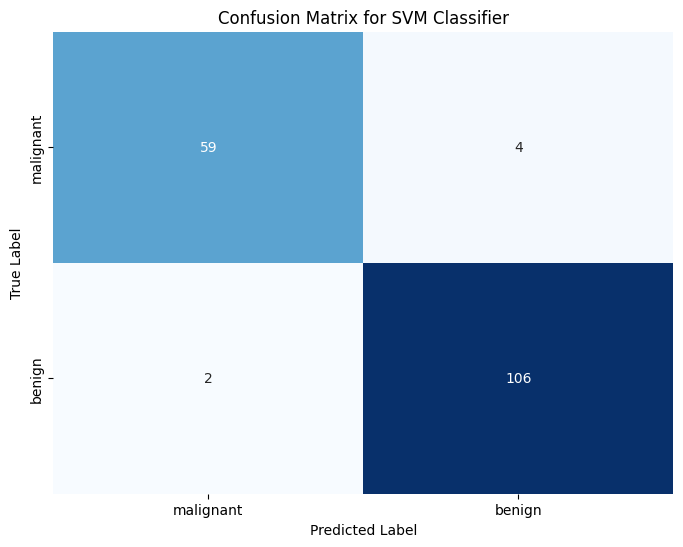

In [82]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Breast Cancer dataset
breast_cancer = datasets.load_breast_cancer()
X = breast_cancer.data
y = breast_cancer.target
class_names = breast_cancer.target_names # For labeling the confusion matrix

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create an SVM Classifier
svm_classifier = svm.SVC(kernel='linear', random_state=42) # Using a linear kernel for simplicity

# Train the classifier on the training data
svm_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred = svm_classifier.predict(X_test)

# Evaluate accuracy (optional, but good practice)
accuracy = accuracy_score(y_test, y_pred)
print(f"SVM Classifier Accuracy: {accuracy:.4f}")

# Compute the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the Confusion Matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SVM Classifier')
plt.show()

Q44. Write a Python program to train an SVM Regressor (SVR) and evaluate its performance using Mean Absolute Error (MAE) instead of MSE.

In [83]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import mean_absolute_error

# Load a housing dataset (e.g., California Housing dataset)
california = datasets.fetch_california_housing()
X = california.data
y = california.target
dataset_name = "California Housing"

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create an SVR model
# Using a radial basis function (RBF) kernel, which is common for SVR
# C and gamma are hyperparameters that often need tuning
svr_model = svm.SVR(kernel='rbf', C=100, gamma=0.1)

# Train the SVR model
svr_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_svr = svr_model.predict(X_test)

# Evaluate the model using Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred_svr)

print(f"SVR Model trained on {dataset_name} dataset:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

SVR Model trained on California Housing dataset:
Mean Absolute Error (MAE): 0.8307


Q45. Write a Python program to train a Naïve Bayes classifier and evaluate its performance using the ROC-AUC score.

Gaussian Naïve Bayes Classifier ROC-AUC Score: 0.9922


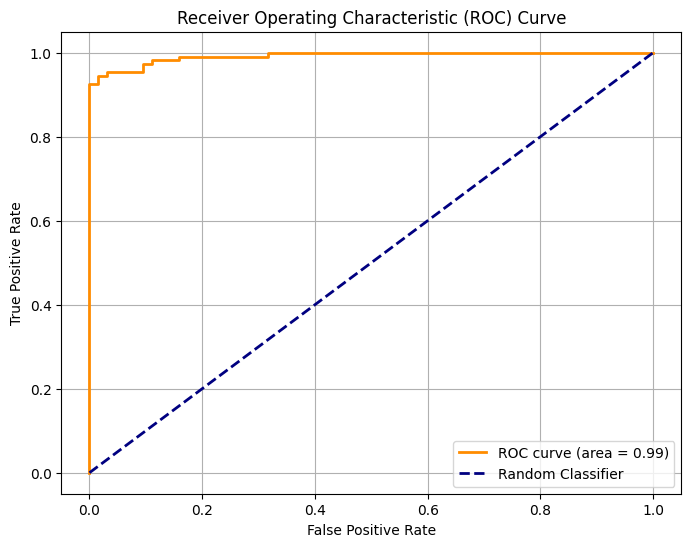

In [84]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Load the Breast Cancer dataset
breast_cancer = datasets.load_breast_cancer()
X = breast_cancer.data
y = breast_cancer.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a Gaussian Naïve Bayes classifier
gnb = GaussianNB()

# Train the classifier on the training data
gnb.fit(X_train, y_train)

# Predict probabilities for the positive class (class 1)
# roc_auc_score requires probability estimates for the positive class
y_scores = gnb.predict_proba(X_test)[:, 1]

# Evaluate the model using ROC-AUC score
roc_auc = roc_auc_score(y_test, y_scores)
print(f"Gaussian Naïve Bayes Classifier ROC-AUC Score: {roc_auc:.4f}")

# Optionally, visualize the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Q46. Write a Python program to train an SVM Classifier and visualize the Precision-Recall Curve.

SVM Classifier Area Under the Precision-Recall Curve (AUC-PR): 0.9960


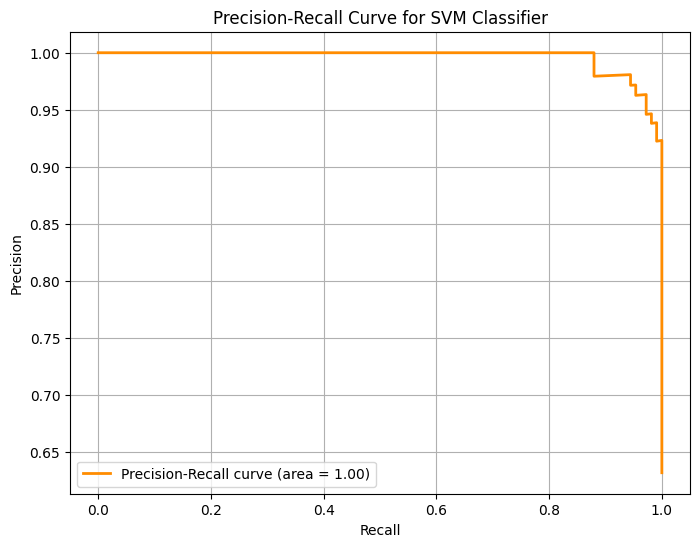

In [85]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Breast Cancer dataset
breast_cancer = datasets.load_breast_cancer()
X = breast_cancer.data
y = breast_cancer.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create an SVM Classifier
# For probability estimates, use probability=True. Note: this adds significant training time.
svm_classifier = svm.SVC(kernel='rbf', probability=True, random_state=42)

# Train the classifier on the training data
svm_classifier.fit(X_train, y_train)

# Get probability estimates for the positive class (class 1)
# The precision_recall_curve needs probability scores or decision function scores
y_scores = svm_classifier.predict_proba(X_test)[:, 1]

# Compute Precision-Recall pairs for different probability thresholds
precision, recall, _ = precision_recall_curve(y_test, y_scores)

# Calculate Area Under the Precision-Recall Curve (AUC-PR)
pr_auc = auc(recall, precision)

print(f"SVM Classifier Area Under the Precision-Recall Curve (AUC-PR): {pr_auc:.4f}")

# Visualize the Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2,
         label=f'Precision-Recall curve (area = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for SVM Classifier')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()